# ICU Infection Prevention Adherence: Data Visualization

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_rater = pd.read_csv('data/icu_adherence_by_rater.csv')
df_items = pd.read_csv('data/icu_adherence_by_item.csv').iloc[:, 1:]

df_rater_avg = df_rater.groupby(['icu_id', 'icu_type'])[['clabsi_score', 'cauti_score', 'vap_score']].mean()
df_rater_avg.reset_index(inplace=True)
df_rater_avg.head()

,icu_id,icu_type,clabsi_score,cauti_score,vap_score
0,1,General,77.845,74.760,64.780
1,2,General,61.175,78.335,80.435
2,3,General,73.135,77.740,76.955
3,4,General,79.310,90.715,77.395
4,5,General,70.785,73.215,87.395


### Distribution of Adherence Scores by ICU Type

A boxplot is more effective at showing the distribution, median, and spread of the adherence scores within each ICU type, than the bar chart included in descriptive_statistics file.

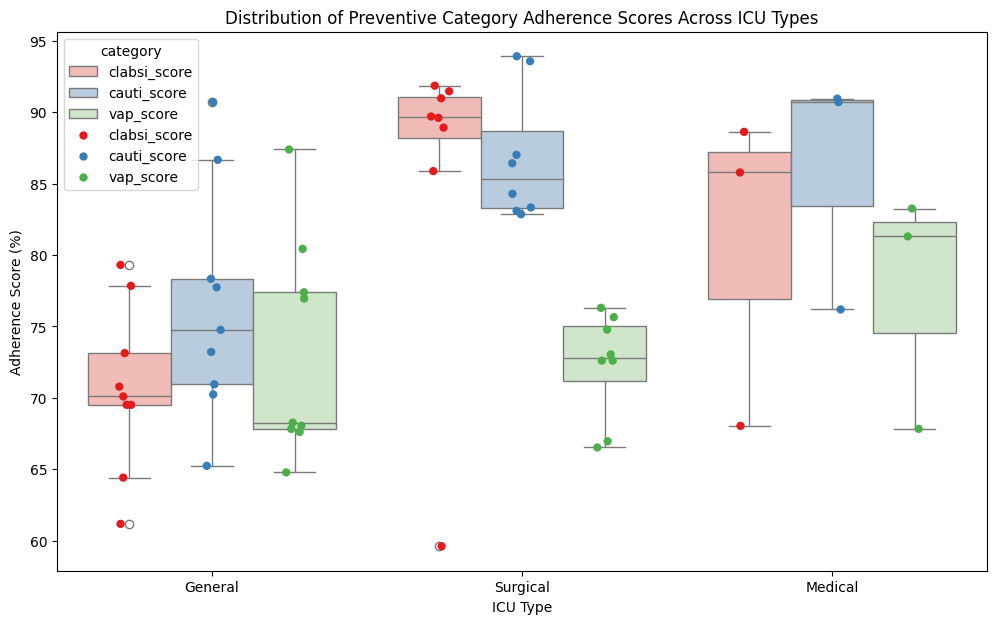

In [3]:
fig, ax = plt.subplots(1, 1, figsize=(12, 7))

df_melted = pd.melt(
    df_rater_avg,
    id_vars=['icu_type'], 
    value_vars=['clabsi_score', 'cauti_score', 'vap_score'], 
    var_name='category', 
    value_name='score'
)

# Boxplot to show distribution summaries
sns.boxplot(data=df_melted, x='icu_type', y='score', hue='category', ax=ax, palette="Pastel1")

# Stripplot to show individual data points
sns.stripplot(
    data=df_melted, x='icu_type', y='score', hue='category', 
    palette="Set1", dodge=True, jitter=True, alpha=1, size=6, ax=ax
)

ax.set_title('Distribution of Preventive Category Adherence Scores Across ICU Types')
ax.set_ylabel('Adherence Score (%)')
ax.set_xlabel('ICU Type')

plt.show()

### ICU Performance Ranking

Let's see how each individual ICU performed. We will calculate an overall mean adherence score for each ICU and visualize the ranking.

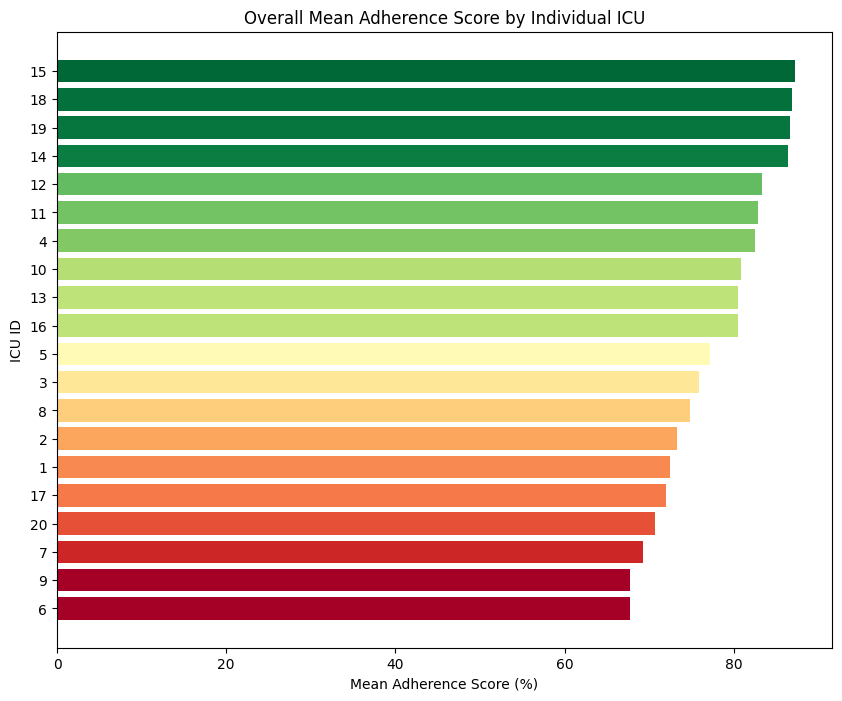

In [4]:
# Calculate a mean score across the three prevention category for each ICU
df_rater_avg['overall_mean'] = df_rater_avg[['clabsi_score', 'cauti_score', 'vap_score']].mean(axis=1)

# Sort by the new mean score to rank the ICUs
df_ranked = df_rater_avg.sort_values('overall_mean', ascending=False)

plt.figure(figsize=(10, 8))

# plt.barh(df_ranked['icu_id'].astype(str), df_ranked['overall_mean'])

norm = plt.Normalize(df_ranked['overall_mean'].min(), df_ranked['overall_mean'].max())
colors = plt.cm.RdYlGn(norm(df_ranked['overall_mean']))
plt.barh(df_ranked['icu_id'].astype(str), df_ranked['overall_mean'], color=colors)

plt.title('Overall Mean Adherence Score by Individual ICU')
plt.xlabel('Mean Adherence Score (%)')
plt.ylabel('ICU ID')

# Invert axis to show highest-performing ICU at the top
plt.gca().invert_yaxis()

plt.show()

### Visualizing Rater Agreement

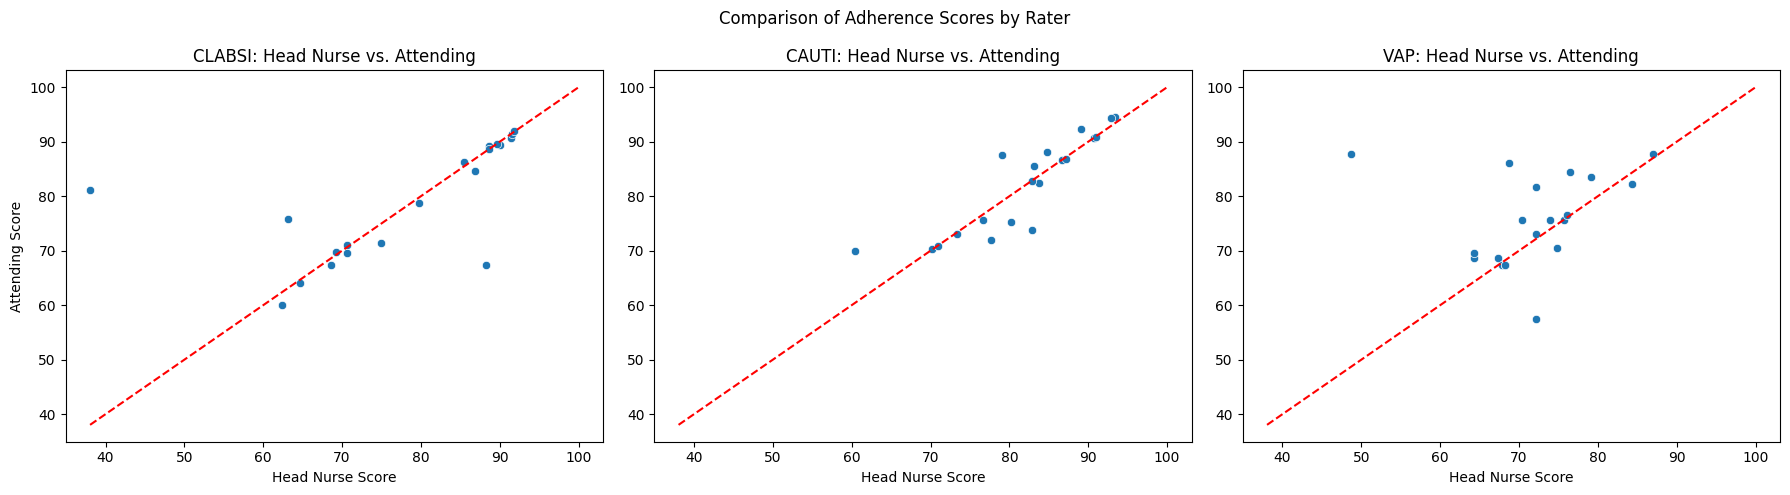

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Comparison of Adherence Scores by Rater')

# Add a reference line for perfect agreement
line_coords = [min(df_rater['clabsi_score'].min(), df_rater['cauti_score'].min(), df_rater['vap_score'].min()), 100]

df_paired = df_rater.pivot(index='icu_id', columns='rater', values=['clabsi_score', 'cauti_score', 'vap_score'])

# CLABSI
sns.scatterplot(ax=axes[0], data=df_paired, x=('clabsi_score', 'HeadNurse'), y=('clabsi_score', 'Attending'))
axes[0].plot(line_coords, line_coords, 'r--')
axes[0].set_title('CLABSI: Head Nurse vs. Attending')
axes[0].set_xlabel('Head Nurse Score')
axes[0].set_ylabel('Attending Score')

# CAUTI
sns.scatterplot(ax=axes[1], data=df_paired, x=('cauti_score', 'HeadNurse'), y=('cauti_score', 'Attending'))
axes[1].plot(line_coords, line_coords, 'r--')
axes[1].set_title('CAUTI: Head Nurse vs. Attending')
axes[1].set_xlabel('Head Nurse Score')
axes[1].set_ylabel('')

# VAP
sns.scatterplot(ax=axes[2], data=df_paired, x=('vap_score', 'HeadNurse'), y=('vap_score', 'Attending'))
axes[2].plot(line_coords, line_coords, 'r--')
axes[2].set_title('VAP: Head Nurse vs. Attending')
axes[2].set_xlabel('Head Nurse Score')
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()